## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [1]:
! git clone https://github.com/arya-rajesh-99/undergrad_ml_assignments
%run ./undergrad_ml_assignments/get_data.py

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
df = pd.read_csv('./undergrad_ml_assignments/data/golub.csv')
df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [4]:
print(df['cancer'].unique())
df['cancer'].value_counts()

['allB' 'allT' 'aml']


,count
cancer,
allB,38
aml,25
allT,9


In [5]:
mapper = {
    'allB': 0,
    'allT': 0,
    'aml': 1
}

df['y'] = df['cancer'].map(mapper)
genes = df.drop(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'y'], axis=1)
y= df['y']

In [6]:
print(df['y'].value_counts())
print(df['y'].isna().sum())

y
0    47
1    25
Name: count, dtype: int64
0


In [7]:
genes.head()

,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,-1363.276427,-1058.585495,-541.469194,74.349803,-1110.082554,-1545.661845,-2037.029616,-1255.990888,-335.480958,-938.425691,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,-796.285053,-1167.103365,7.538493,83.544731,-1116.432539,-1731.392100,249.376523,-1636.960108,-149.080421,-222.783440,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,-679.139168,-1069.832308,-690.301829,-112.075981,-1199.319178,-1286.387935,-605.465604,-1043.041921,-728.254877,388.011238,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,-1164.400197,-1109.939891,-990.127218,-238.574994,-1264.607160,-1218.860503,-1255.893511,-1009.732928,-521.768585,-926.953263,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,-1299.653758,-1401.998536,-1077.543813,-437.344560,-1386.755697,-1726.453259,-1499.988218,-1219.084464,-994.796971,-670.342247,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
mse = lambda y,y_hat: np.sum( (y-y_hat)**2 )/len(y)

y = df['y']
x = genes
model = LinearRegression()
model.fit(x,y)
y_hat = model.predict(x)
print(f'Mean squared error:{mean_squared_error(y, y_hat)}')
print(f'Model Intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })
resid = y - y_hat
resid.describe()

Mean squared error:1.2522824482837894e-30
Model Intercept: 0.7151984878419668


,y
count,7.200000e+01
mean,5.396917e-17
std,1.125596e-15
min,-2.220446e-15
25%,-5.828671e-16
50%,0.000000e+00
75%,7.494005e-16
max,2.553513e-15


Text(0.5, 0, 'Residual')

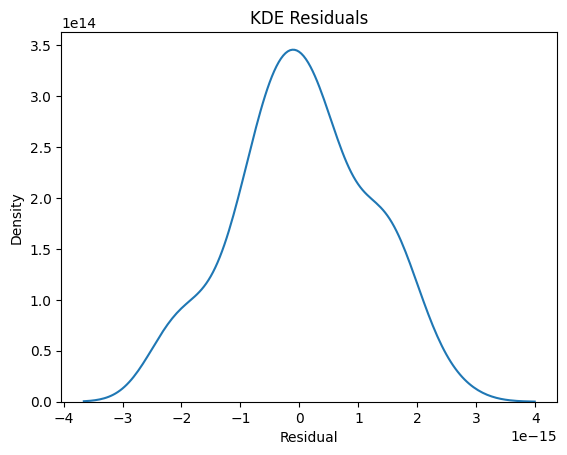

In [10]:
sns.kdeplot(resid)
plt.title("KDE Residuals")
plt.xlabel("Residual")

Text(0, 0.5, 'Actual Outcome')

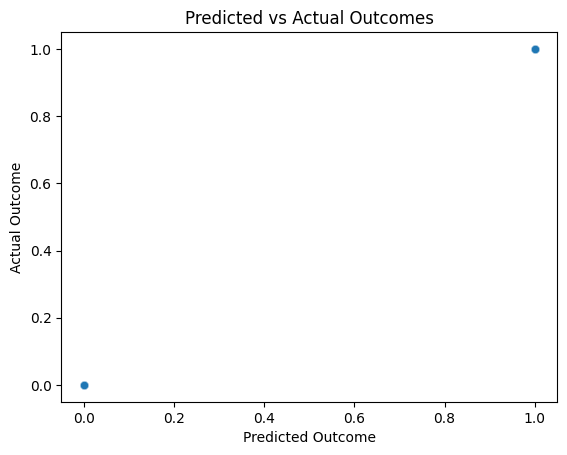

In [11]:
sns.scatterplot(x=y_hat, y=y, alpha = 0.3)
plt.title("Predicted vs Actual Outcomes")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")

In [15]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import make_scorer


kfold = KFold(n_splits=10, shuffle=True, random_state=100)

mse_scorer = make_scorer(mean_squared_error, greater_is_better=True)

scores = cross_val_score(
    model,x,y,
    cv=kfold,
    scoring= 'neg_mean_squared_error'
)
msescore = -scores
print("Fold scores:", msescore)
print("Mean score:", np.mean(msescore))
print("Median score:", np.median(msescore))
print("Std dev:", np.std(msescore))

Fold scores: [0.02265367 0.04875751 0.06347474 0.06304086 0.09383082 0.08300696
 0.0207161  0.01969831 0.02087605 0.02271393]
Mean score: 0.045876895088525556
Median score: 0.03573571993995745
Std dev: 0.027037144984588028


30 selected
7099 discarded


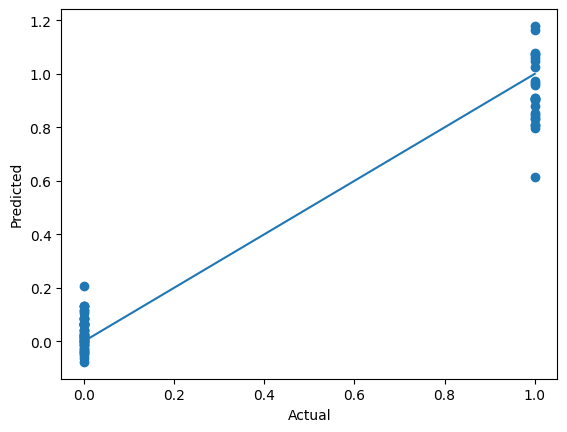

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, lasso_path

model = LassoCV(cv=10, random_state = 100)
model = model.fit (genes,y)
mean_mse = model.mse_path_.mean(axis=1)

coefs = model.coef_

selected_genes = genes.columns[coefs != 0] # when they are not equal to zero they are discard
discarded_genes = genes.columns[coefs == 0] #when equal to zero they are discarded

print(len(selected_genes), "selected")
print(len(discarded_genes), "discarded")

plt.scatter(y, model.predict(genes))
plt.plot([0,1],[0,1])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.059e-03, tolerance: 1.523e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.536e-03, tolerance: 1.523e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.316e-03, tolerance: 1.523e

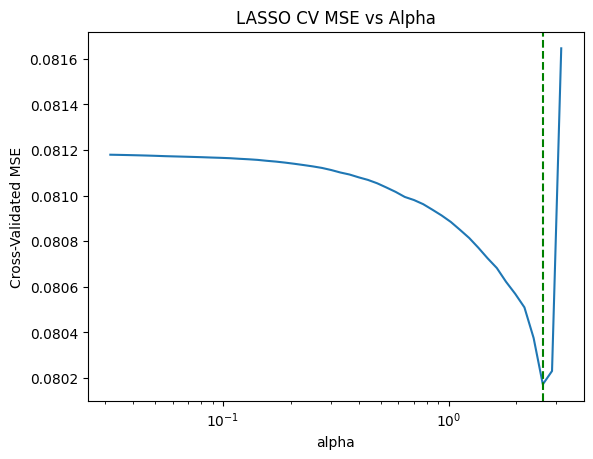

Optimal alpha: 2.620398528858349


In [21]:
alpha_grid = np.logspace(-1.5, 0.5, 50)

model = LassoCV(cv=10, alphas=alpha_grid, random_state=100)
model.fit(x, y)

mean_mse = np.mean(model.mse_path_, axis=1)
alpha_star = model.alpha_

sns.lineplot(x=model.alphas_, y=mean_mse)
plt.axvline(x=alpha_star, color='green', linestyle='--', linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("LASSO CV MSE vs Alpha")
plt.show()

print("Optimal alpha:", alpha_star)